## Explaining CNNs

This notebook implements integrated gradients and Grad-CAM on a cats vs dogs classifier and compares what they say about the model's decisions. First there's a setup section that trains the model, then the two explainer sections, then a comparison at the end.

Run this on a GPU runtime, training takes a few minutes.

In [1]:
%pip -q install captum datasets torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 9.7 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from torchvision import transforms, models
from torch.utils.data import DataLoader
from captum.attr import IntegratedGradients, LayerGradCam, LayerAttribution

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
print(device)

cuda


### Setup: the model

I didn't have my model saved from the earlier cats vs dogs work, so I set one up here so the notebook runs end to end. I first tried training the small convnet from the lecture from scratch, but with only 2,000 training images it stalled around 70-75% even after 35 epochs, and the maps from a weak model aren't really telling you anything. So I fine-tune a pretrained ResNet-18 instead, which is the move the small-datasets lecture ends on anyway. The explainers below don't care where the model came from, they attach the same way.

In [3]:
ds = load_dataset("pantelism/cats-vs-dogs")
print(ds)

README.md:   0%|          | 0.00/602 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 45.7MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.3MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1000
    })
})


In [4]:
IMG_SIZE = 180
MEAN = torch.tensor([0.485, 0.456, 0.406])
STD = torch.tensor([0.229, 0.224, 0.225])

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN.tolist(), STD.tolist()),
])
test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN.tolist(), STD.tolist()),
])

def denorm(img):
    return (img * STD[:, None, None] + MEAN[:, None, None]).clamp(0, 1)

class CatsDogs(torch.utils.data.Dataset):
    def __init__(self, split, tf):
        self.split = split
        self.tf = tf
    def __len__(self):
        return len(self.split)
    def __getitem__(self, i):
        row = self.split[i]
        img = row["image"].convert("RGB")
        return self.tf(img), row["label"]

split_names = list(ds.keys())
train_name = "train" if "train" in split_names else split_names[0]
test_name = "test" if "test" in split_names else ("validation" if "validation" in split_names else split_names[-1])

if train_name == test_name:
    full = ds[train_name].train_test_split(test_size=0.2, seed=42)
    train_split, test_split = full["train"], full["test"]
else:
    train_split, test_split = ds[train_name], ds[test_name]

train_ds = CatsDogs(train_split, train_tf)
test_ds = CatsDogs(test_split, test_tf)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2)

label_names = train_split.features["label"].names if hasattr(train_split.features["label"], "names") else ["cat", "dog"]
print(len(train_ds), len(test_ds), label_names)

2000 1000 ['cat', 'dog']


In [5]:
model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()

EPOCHS = 3
for epoch in range(EPOCHS):
    model.train()
    total, correct, running = 0, 0, 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        opt.step()
        running += loss.item() * len(y)
        correct += (out.argmax(1) == y).sum().item()
        total += len(y)
    model.eval()
    t_total, t_correct = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            t_correct += (model(x).argmax(1) == y).sum().item()
            t_total += len(y)
    print(f"epoch {epoch+1}: train loss {running/total:.3f}, train acc {correct/total:.3f}, test acc {t_correct/t_total:.3f}")

torch.save(model.state_dict(), "cats_dogs_resnet18.pt")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 114MB/s]


epoch 1: train loss 0.185, train acc 0.906, test acc 0.970
epoch 2: train loss 0.040, train acc 0.985, test acc 0.972
epoch 3: train loss 0.023, train acc 0.993, test acc 0.969


### Picking the images to explain

I need at least three images the model gets right and one it gets wrong, so I just scan the test set and keep the first few of each.

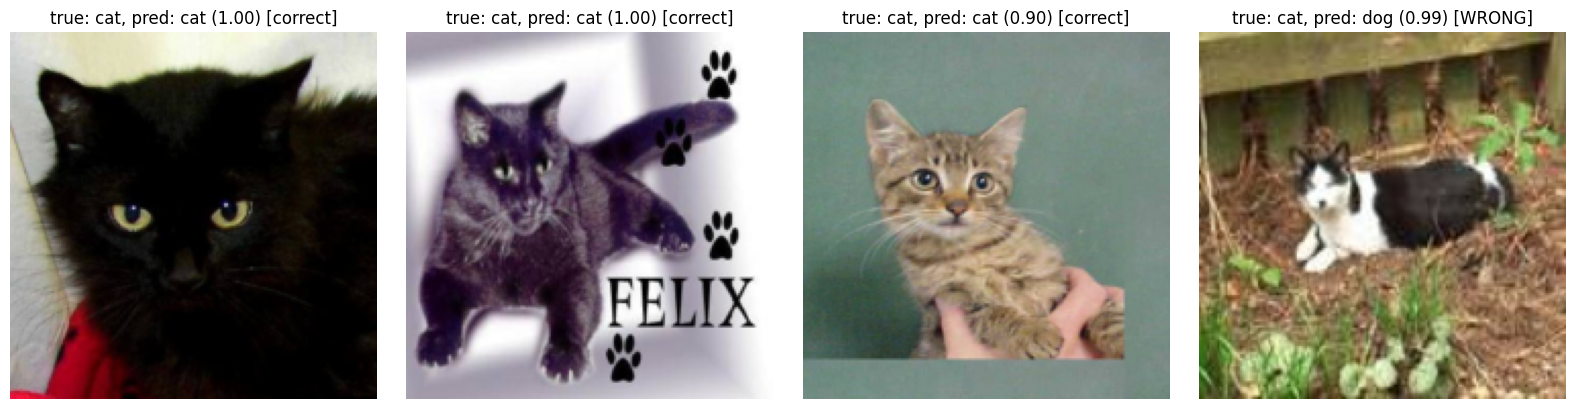

In [6]:
model.eval()
correct_examples = []
wrong_examples = []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device))
        probs = torch.softmax(out, dim=1).cpu()
        preds = probs.argmax(1)
        for i in range(len(y)):
            item = (x[i], y[i].item(), preds[i].item(), probs[i, preds[i]].item())
            if preds[i] == y[i] and len(correct_examples) < 3:
                correct_examples.append(item)
            elif preds[i] != y[i] and len(wrong_examples) < 1:
                wrong_examples.append(item)
        if len(correct_examples) >= 3 and len(wrong_examples) >= 1:
            break

examples = correct_examples + wrong_examples
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (img, true, pred, p) in zip(axes, examples):
    ax.imshow(denorm(img).permute(1, 2, 0))
    ok = "correct" if true == pred else "WRONG"
    ax.set_title(f"true: {label_names[true]}, pred: {label_names[pred]} ({p:.2f}) [{ok}]")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Integrated gradients

The idea: a plain gradient asks "if I nudge this pixel, how much does the score change", but that breaks when a neuron is saturated. The model might rely heavily on some region and still have near zero gradient there because the activation is already maxed out. Integrated gradients fixes this by not looking at the gradient at just the input. It picks a baseline image, walks along the straight line from the baseline to the real input, and adds up the gradients at every step along the way. So even if the gradient is flat at the end point, the steps where the feature was "turning on" get counted.

The baseline matters because attributions are relative to it. It's supposed to be an input that means "nothing" to the model, and here I use an all black image (in the normalized space the model sees, so actually black, not the ImageNet mean), which is the standard choice for photos. The nice property you get is completeness: the attributions across all pixels sum up to (score at input) minus (score at baseline), so the map really does account for the whole prediction.

One limitation: the answer depends on the baseline you picked, and black isn't neutral for every problem. If dark pixels are themselves informative (say a black cat), attributions against a black baseline can get weird for those regions. There's no universally right baseline and the paper itself discusses this.

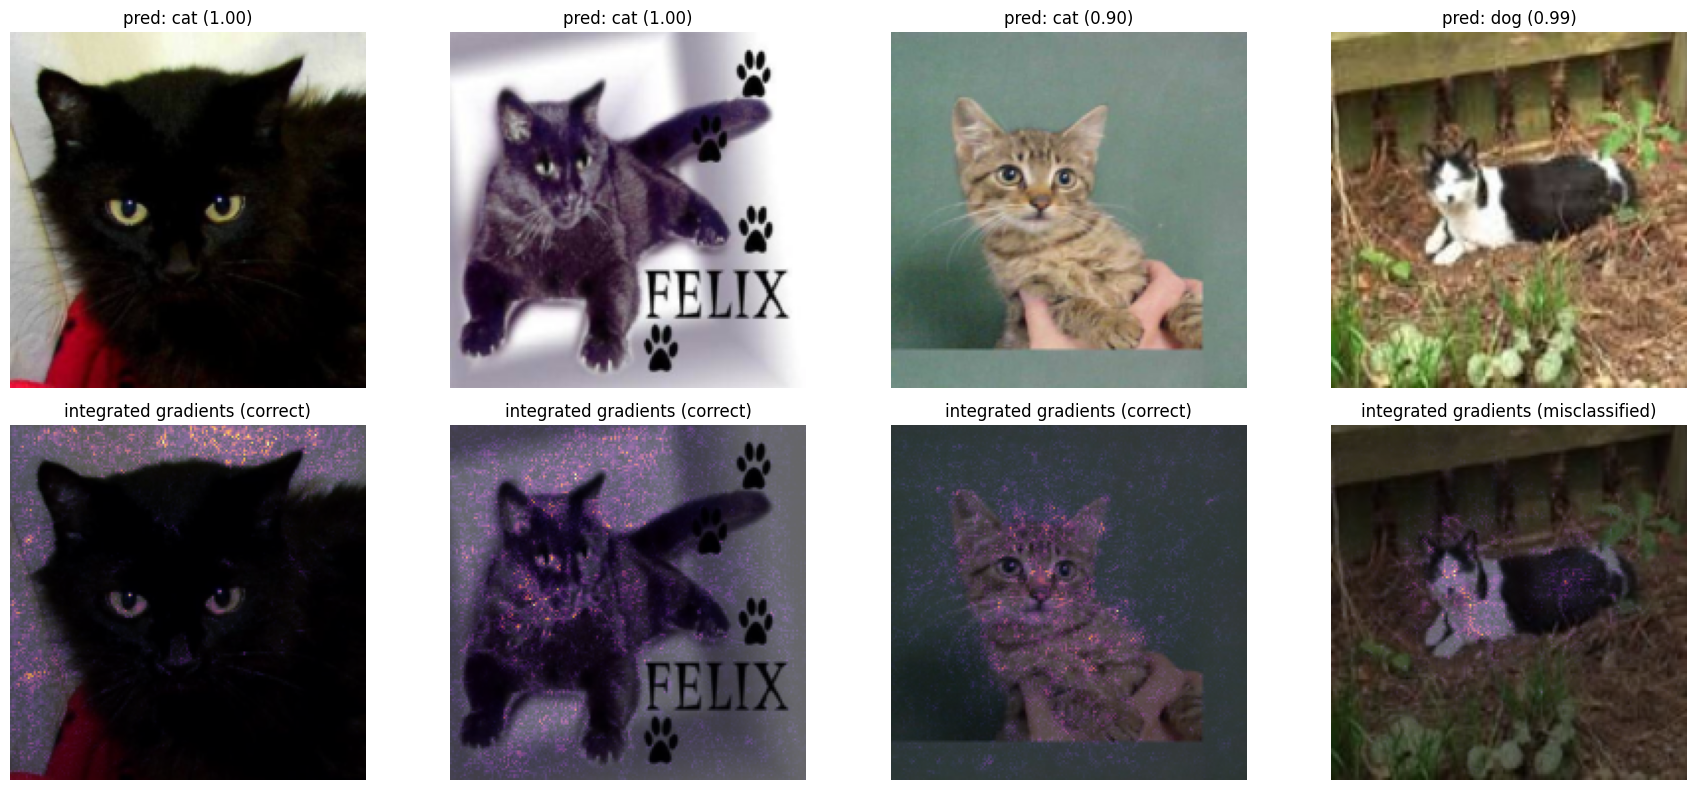

In [7]:
ig = IntegratedGradients(model)
black_baseline_1px = ((torch.zeros(3) - MEAN) / STD).view(1, 3, 1, 1).to(device)

def show_ig(img, true, pred, p, ax_img, ax_map):
    inp = img.unsqueeze(0).to(device)
    inp.requires_grad_()
    baseline = black_baseline_1px.expand_as(inp)
    attr = ig.attribute(inp, baselines=baseline, target=pred, n_steps=50)
    attr = attr.squeeze(0).detach().cpu()
    heat = attr.abs().sum(0)
    heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
    disp = denorm(img).permute(1, 2, 0)
    ax_img.imshow(disp)
    ax_img.set_title(f"pred: {label_names[pred]} ({p:.2f})")
    ax_img.axis("off")
    ax_map.imshow(disp)
    ax_map.imshow(heat, cmap="inferno", alpha=0.6)
    ok = "correct" if true == pred else "misclassified"
    ax_map.set_title(f"integrated gradients ({ok})")
    ax_map.axis("off")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for col, (img, true, pred, p) in enumerate(examples):
    show_ig(img, true, pred, p, axes[0][col], axes[1][col])
plt.tight_layout()
plt.show()

**Captions (IG), left to right:**

1. Black cat: the attributions cluster around the eyes and the outline of the face, and the solid black fur barely gets any attribution. That's actually the black-baseline limitation from above showing up in practice: black pixels are the baseline, so IG has nothing to attribute to them.
2. Felix poster: the speckle sits on the cat figure itself, with a little spilling onto the white poster area but ignoring the text and paw prints.
3. Tabby kitten: dense attribution over the kitten's face and body, the green wall behind it stays almost completely dark.
4. Misclassified garden cat: the attribution is diffuse, spread over the cat and the surrounding plants and ground with no clean focus, which fits the model being confidently wrong here.

## Grad-CAM

Grad-CAM works at the other end of the network. Instead of scoring input pixels, it looks at the feature maps of a convolutional layer, weights each map by how much the class score cares about it (the gradient flowing into that map, averaged spatially), sums them up, and passes it through a ReLU. What's left is a coarse heatmap over that layer's spatial grid saying which regions pushed the prediction toward the chosen class. You then upsample it to the input size to overlay it.

The target layer matters because it sets the trade-off between semantics and resolution. I use the last conv block, which is standard: it's the most class-aware layer that still has spatial structure. Earlier layers give sharper maps but they respond to edges and textures, not "dog face", so the map stops being about the decision. I target the last residual block (layer4), whose output is only 6x6 at this input size, which is why the heatmap looks so blobby after upsampling.

One limitation: the resolution. A 6x6 grid can say "the decision came from this general region" but it can't separate the dog's eyes from its nose, and a small but decisive detail can get smeared over a big blob. It also only produces positive evidence for one class at a time because of the ReLU, so it won't show you what argued against the prediction.

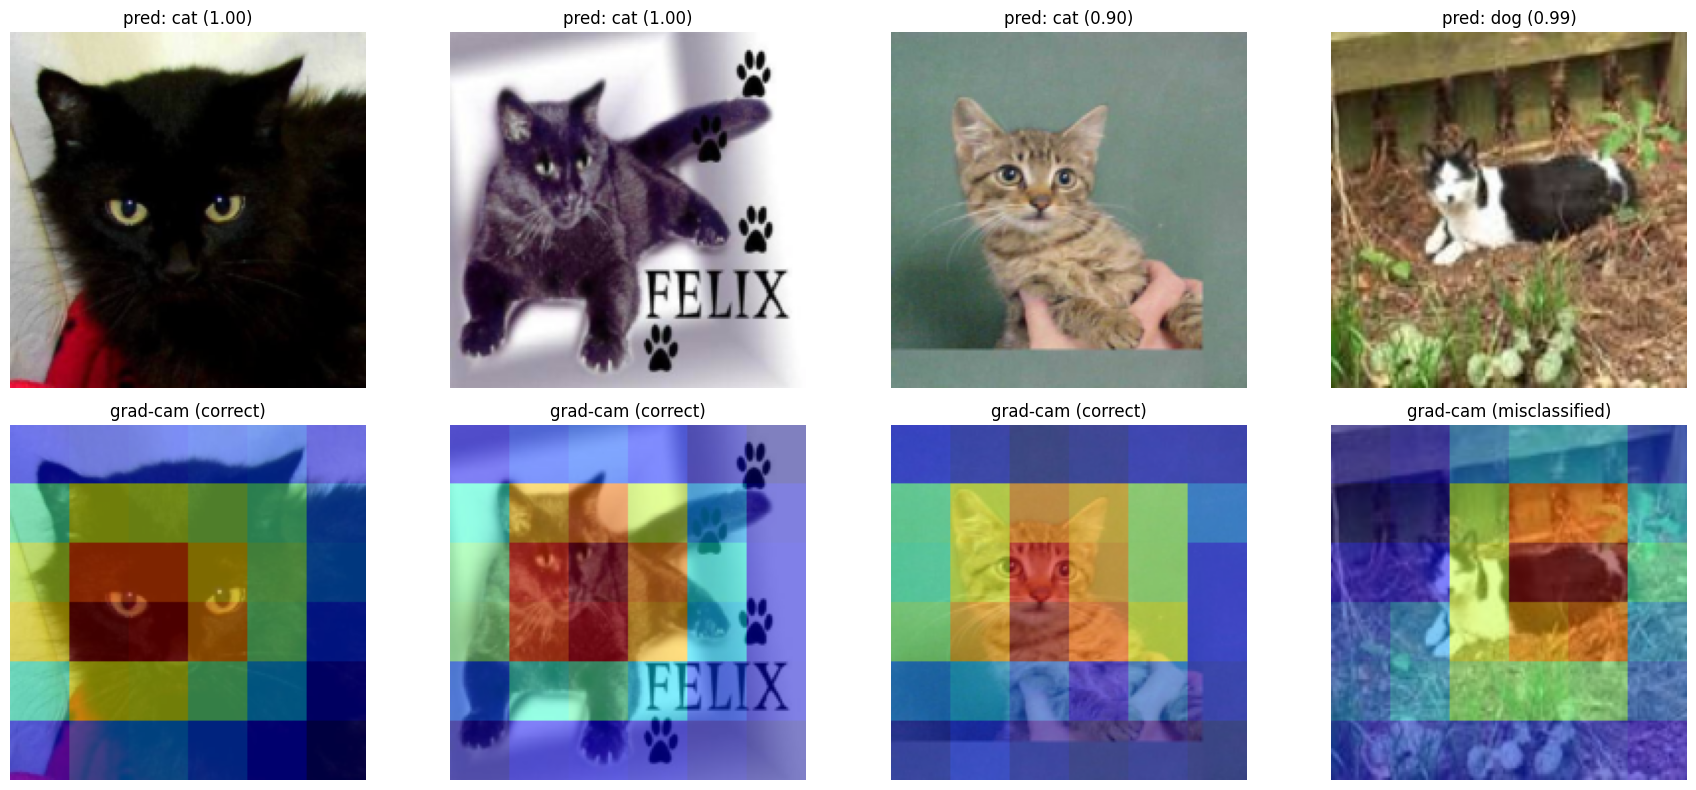

In [8]:
target_layer = model.layer4[-1]
gradcam = LayerGradCam(model, target_layer)

def show_gc(img, true, pred, p, ax_img, ax_map):
    inp = img.unsqueeze(0).to(device)
    attr = gradcam.attribute(inp, target=pred)
    up = LayerAttribution.interpolate(attr, (IMG_SIZE, IMG_SIZE))
    heat = up.squeeze().detach().cpu()
    heat = torch.relu(heat)
    heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
    disp = denorm(img).permute(1, 2, 0)
    ax_img.imshow(disp)
    ax_img.set_title(f"pred: {label_names[pred]} ({p:.2f})")
    ax_img.axis("off")
    ax_map.imshow(disp)
    ax_map.imshow(heat, cmap="jet", alpha=0.5)
    ok = "correct" if true == pred else "misclassified"
    ax_map.set_title(f"grad-cam ({ok})")
    ax_map.axis("off")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for col, (img, true, pred, p) in enumerate(examples):
    show_gc(img, true, pred, p, axes[0][col], axes[1][col])
plt.tight_layout()
plt.show()

**Captions (Grad-CAM), left to right:**

1. Black cat: one hot region centered directly on the face and eyes, edges of the frame stay cold.
2. Felix poster: the hot blob covers the cat's head and upper body, the text and paw print graphics stay cool.
3. Tabby kitten: the heat sits on the kitten's face and chest, the wall and the hand holding it stay cold.
4. Misclassified garden cat: interestingly the hot region is still on and around the cat, not the background, so the model looked at the animal and still called it a dog at 0.99.

## Comparing the two

Where they agree: on the three correct images both methods land on the cat, IG at the pixel level and Grad-CAM as a region, and the strong IG pixels fall inside the Grad-CAM blob. Two different methods pointing at the same place is decent evidence the model is actually using the animal and not something like the background or the poster text in the Felix image.

Where they disagree: IG is way noisier, it scatters attribution on random pixels that Grad-CAM just smooths over. The black cat has an actual disagreement though. Grad-CAM lights up the whole face region but IG goes almost silent on the solid black fur. That's the baseline thing from earlier showing up for real, black pixels are the baseline so IG literally has nothing to attribute to them. Same prediction, but you can see one method's blind spot through the other one.

The misclassified garden cat is the most interesting one. Grad-CAM shows the model was looking at the animal, not the background, and IG is just spread out over the cat and the plants around it. So it's not a background shortcut, the model looked at the right spot and still called a black and white cat lying in a garden a dog at 0.99. My guess is it's the appearance and setting, the coloring plus the lying down pose plus being outside in a yard all look more like typical dog photos. Accuracy would just say wrong, the maps at least tell you what kind of wrong.